In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_parquet('/content/drive/MyDrive/TFM/favorita_filtrado.parquet')
df.shape

(4102969, 19)

# 1. Corregir ventas duplicadas por festivos

In [4]:
!pip install -q kaggle
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [5]:
#descarga de feriados
!kaggle competitions download -c favorita-grocery-sales-forecasting -f holidays_events.csv.7z
!ls

100% 1.85k/1.85k [00:00<00:00, 4.41MB/s]

drive  holidays_events.csv.7z  kaggle.json  sample_data


In [6]:
#descomprimir
!apt-get install -y p7zip-full -q
!7z x holidays_events.csv.7z -y

Reading package lists...
Building dependency tree...
Reading state information...
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan         1 file, 1898 bytes (2 KiB)

Extracting archive: holidays_events.csv.7z
--
Path = holidays_events.csv.7z
Type = 7z
Physical Size = 1898
Headers Size = 146
Method = LZMA2:24k
Solid = -
Blocks = 1

  0%    Everything is Ok

Size:       22309
Compressed: 1898


In [7]:
#Carga de datos
import pandas as pd

holidays = pd.read_csv('holidays_events.csv', parse_dates=['date'])
print(holidays['locale'].value_counts())
print(holidays['locale_name'].value_counts())

locale
National    174
Local       152
Regional     24
Name: count, dtype: int64
locale_name
Ecuador                           174
Quito                              13
Guaranda                           12
Riobamba                           12
Latacunga                          12
Ambato                             12
Guayaquil                          11
Cuenca                              7
Ibarra                              7
Imbabura                            6
Cotopaxi                            6
Libertad                            6
Manta                               6
Puyo                                6
El Carmen                           6
Machala                             6
Cayambe                             6
Esmeraldas                          6
Santo Domingo                       6
Quevedo                             6
Santa Elena                         6
Santo Domingo de los Tsachilas      6
Loja                                6
Salinas                          

In [8]:
ciudades_pichincha = df.loc[df['state'] == 'Pichincha', 'city'].unique()
print(ciudades_pichincha)

['Quito' 'Cayambe']


In [9]:
#Tabla de festivos aplicados a pichincha
holidays_pichincha = holidays[
    (holidays['locale'] == 'National') |
    ((holidays['locale'] == 'Regional') & (holidays['locale_name'] == 'Pichincha')) |
    ((holidays['locale'] == 'Local') & (holidays['locale_name'].isin(ciudades_pichincha)))
].copy()

holidays_pichincha = holidays_pichincha.drop_duplicates(subset='date', keep='first')
holidays_pichincha.shape

(187, 6)

In [10]:
#Recupero tabla base y elimino duplicados
columnas_feriado = ['type_holiday', 'locale', 'locale_name', 'description', 'transferred']
df_base = df.drop(columns=columnas_feriado).drop_duplicates()
df_base.shape

(4025458, 14)

In [11]:
#Unión de tablas
df_limpio = df_base.merge(
    holidays_pichincha[['date', 'type', 'description', 'transferred']],
    on='date', how='left', suffixes=('', '_holiday')
)
df_limpio.shape

(4025458, 17)

In [13]:
df_limpio.to_parquet('/content/drive/MyDrive/TFM/favorita_filtrado.parquet')

# 2. Tratamiento de ventas negativas

In [14]:
negativos = df_limpio[df_limpio['unit_sales'] < 0]
negativos['unit_sales'].describe()

,unit_sales
count,186.000000
mean,-3.413979
std,8.474158
min,-80.000000
25%,-2.000000
50%,-1.000000
75%,-1.000000
max,-1.000000


In [15]:
negativos[['date', 'store_nbr', 'item_nbr', 'unit_sales', 'family']].sort_values('unit_sales').head(10)

,date,store_nbr,item_nbr,unit_sales,family
369822,2013-10-31,46,838215,-80.0,DAIRY
2024881,2015-10-28,47,457727,-54.0,DAIRY
3488566,2017-03-03,8,957096,-40.0,DAIRY
172119,2013-05-26,8,789905,-34.0,DAIRY
1019573,2014-09-09,45,1239905,-27.0,DAIRY
103065,2013-03-30,3,859966,-20.0,DAIRY
2998042,2016-09-26,44,838216,-18.0,DAIRY
206490,2013-06-23,8,179615,-18.0,DAIRY
3209610,2016-12-05,7,508947,-17.0,DAIRY
3465078,2017-02-24,3,939207,-15.0,DAIRY


In [16]:
# Llevar a cero los valores negativos
df_limpio['unit_sales'] = df_limpio['unit_sales'].clip(lower=0)

# 3. Tratamiento de vacíos en el precio del petróleo

In [17]:
df_limpio = df_limpio.sort_values('date')
df_limpio['dcoilwtico'] = df_limpio['dcoilwtico'].ffill().bfill() #ffill arrastra el último precio a los espacios en blanco y bfill en caso de que el primer dato no tenga dato

# 4. Tratamiento de vacíos en 'onpromotion'


In [18]:
df_limpio['onpromotion'] = df_limpio['onpromotion'].fillna(False).astype(bool) #vacío significa que no tenía promoción

In [19]:
df_limpio.isnull().sum()

,0
id,0
date,0
store_nbr,0
item_nbr,0
unit_sales,0
onpromotion,0
city,0
state,0
type,0
cluster,0


In [20]:
#Guardar la versión limpia
df_limpio.to_parquet('/content/drive/MyDrive/TFM/favorita_filtrado.parquet')

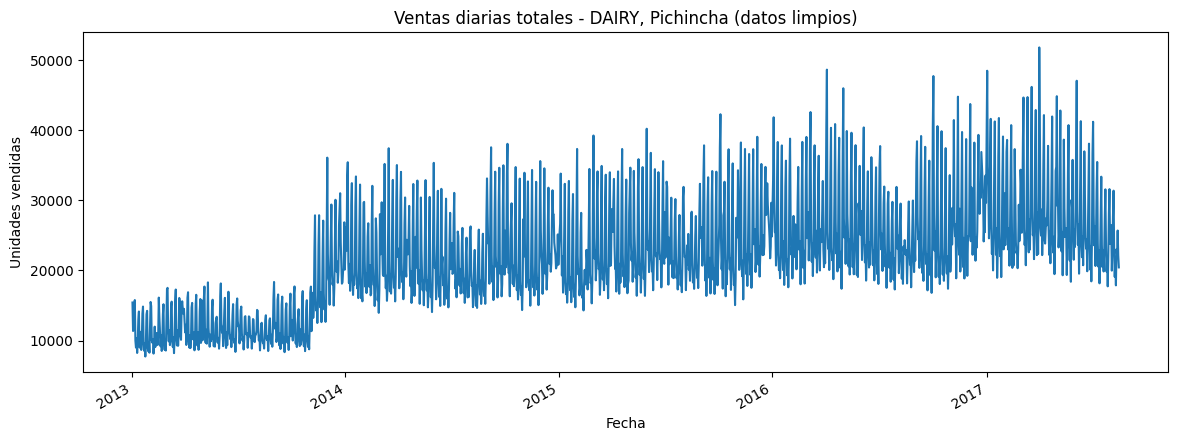

In [21]:
import matplotlib.pyplot as plt

ventas_diarias = df_limpio.groupby('date')['unit_sales'].sum()

plt.figure(figsize=(14, 5))
ventas_diarias.plot()
plt.title('Ventas diarias totales - DAIRY, Pichincha (datos limpios)')
plt.xlabel('Fecha')
plt.ylabel('Unidades vendidas')
plt.show()